In [1]:
import numpy as np
from pathlib import Path
import optuna
from optuna.samplers import TPESampler
import multiprocessing as mp
import pandas as pd

# Custom modules
import utils
from constraints import constraints as constraints_fn



/home/gtl23/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:


# Update with your DB path and study name
DB_PATH = "sqlite:///serpent_optuna.db"
# DB_PATH = "sqlite:////home/gtl23/optimisation/BA_opti/serpent_optuna.db"
STUDY_NAME = "geom_opti_TH_12"  # Match the study_name used in create_study

# Load study
study = optuna.load_study(study_name=STUDY_NAME, storage=DB_PATH)
print(f"Loaded study with {len(study.trials)} total trials.")

# Convert trials to a clean Pandas DataFrame
df = study.trials_dataframe()
df.head()

Loaded study with 173 total trials.


,number,value,datetime_start,datetime_complete,duration,params_fuel_enrichment,params_fuel_radius,params_gad_enrichment,params_gd_axis_w_0,params_gd_axis_w_1,...,user_attrs_linear_power,user_attrs_n_branches,user_attrs_pitch,user_attrs_total_gad_pins,user_attrs_total_guide_tubes,user_attrs_total_pins,system_attrs_constraints,system_attrs_fixed_params,system_attrs_tpe:relative_params:0,state
0,0,1.001888e+08,2026-09-17 12:32:42.048550,2026-09-17 13:02:46.067139,0 days 00:30:04.018589,3.50,0.48,0.700,0.233333,0.700000,...,56374.019472,5.0,0.01265,16,24,289,"[-3.4288000000000007, 1.455200000000001, -6.09...","{'fuel_enrichment': 3.5, 'gad_enrichment': 0.7...",NaN,COMPLETE
1,1,4.332059e+07,2026-09-17 12:32:42.136538,2026-09-17 13:04:42.733004,0 days 00:32:00.596466,1.65,0.47,NaN,0.403062,0.832691,...,67152.339368,5.0,0.01265,0,4,289,"[-2.360000000000002, 2.9729800000000006, -8.62...",NaN,NaN,COMPLETE
2,2,NaN,2026-09-17 12:32:42.202992,2026-09-17 12:33:45.715206,0 days 00:01:03.512214,1.15,0.48,1.425,0.564947,0.472255,...,NaN,NaN,0.01265,24,16,289,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",NaN,NaN,PRUNED
3,3,5.257653e+07,2026-09-17 12:32:42.265839,2026-09-17 12:55:59.083880,0 days 00:23:16.818041,3.00,0.37,NaN,0.609517,0.186840,...,53407.356572,5.0,0.01265,0,44,289,"[-7.5748000000000015, 2.6953000000000005, 3.05...",NaN,NaN,COMPLETE
4,4,NaN,2026-09-17 12:32:42.346868,2026-09-17 12:33:49.447054,0 days 00:01:07.100186,0.85,0.48,0.725,0.258096,0.556334,...,NaN,NaN,0.01265,32,28,289,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",NaN,NaN,PRUNED


In [3]:
from optuna.trial import TrialState

completed = study.get_trials(states=[TrialState.COMPLETE])
pruned = study.get_trials(states=[TrialState.PRUNED])
failed = study.get_trials(states=[TrialState.FAIL])

print(f"Completed: {len(completed)} | Pruned: {len(pruned)} | Failed: {len(failed)}")

Completed: 89 | Pruned: 79 | Failed: 0


In [4]:
import utils

print(utils.__file__)

/home/gtl23/optimisation/BA_opti/Serpent_Opti/utils/__init__.py


In [53]:
for t in study.trials:
        print(f"\nTrial {t.number}: Value = {t.value}, Params = {t.params}")
        print(f"User Attributes: {t.user_attrs}")
        print(constraints_fn(t,output_dir = "",currently_optimising = False))


Trial 0: Value = 0.109253, Params = {'fuel_enrichment': 0.1, 'gd_conc': 10.3, 'gad_enrichment': 0.9500000000000001}
User Attributes: {'keff_bol': 0.109253}
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

Trial 1: Value = 1.12568, Params = {'fuel_enrichment': 5.25, 'gd_conc': 3.2, 'gad_enrichment': 1.0250000000000001}
User Attributes: {'keff_bol': 1.12568}
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

Trial 2: Value = 1.13303, Params = {'fuel_enrichment': 5.75, 'gd_conc': 6.5, 'gad_enrichment': 0.225}
User Attributes: {'keff_bol': 1.13303}
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

Trial 3: Value = 3.3, Params = {'fuel_enrichment': 3.3000000000000003, 'gd_conc': 10.700000000000001, 'gad_enrichment': 0.30000000000000004}
User Attributes: {'branch_keff': {'nominal': [0.906351], 'hfp_mtc': [0.975969], 'hzp_base': [0.833505], 'hzp_mtc': [0.625662], 'rodIn_cold': [0.882328]}, 'burn_days': [3.2778], 'burnup_points': [0.1, 7.0, 22.0, 38.0, 60.0], 'keff_bol': 0.887687, 'keff

In [5]:
import optuna

trials_data = []

for t in study.trials:
    if t.state != optuna.trial.TrialState.COMPLETE or t.value is None:
        continue

    g_values = constraints_fn(t,output_dir = "",currently_optimising = False)
    total_violation = sum(max(0.0, g) for g in g_values)

    # Safely extract attributes
    fpin_dict = t.user_attrs.get("fpin_by_branch", {})
    fpin_nominal = fpin_dict.get("nominal") if isinstance(fpin_dict, dict) else None

    trials_data.append({
        "number": t.number,
        "value": t.value,
        "violation": total_violation,
        "fpin": fpin_nominal,
        "g_vals": g_values,
        "params": t.params,
        "fpin_by_branch": fpin_dict,
        "geo_name": t.user_attrs.get("geo_name"),
    })

if not trials_data:
    print("No completed trials found in study.")
else:
    # 1. Top 5 Best Overall (Sort by violation ASC, then objective value ASC)
    best_overall = sorted(
        trials_data, 
        key=lambda x: (x["violation"], x["value"])
    )[:20]

    # 2. Top 5 Best Power Peaking (Sort by violation ASC, then fpin ASC)
    best_fpin = sorted(
        trials_data, 
        key=lambda x: (x["violation"], x["fpin"] if x["fpin"] is not None else float("inf"))
    )[:5]

    def display_trials(heading, trials):
        print(f"\n{'=' * 20} {heading} {'=' * 20}")
        for rank, item in enumerate(trials, start=1):
            status = "Feasible" if item["violation"] == 0.0 else "Infeasible"
            fpin_str = f"{item['fpin']:.5f}" if isinstance(item["fpin"], (int, float)) else item["fpin"]
            
            print(f"Rank {rank} | Trial #{item['number']} [{status}]")
            print(f"  Objective Value : {item['value']}")
            print(f"  Power Peaking   : {item['fpin_by_branch']}")
            print(f"  Total Violation : {item['violation']}")
            print(f"  Geo Name        : {item['geo_name']}")
            print(f"  g-values        : {item['g_vals']}")
            print(f"  Parameters      : {item['params']}")
            print("-" * 55)

    display_trials("TOP 5 BEST OVERALL TRIALS", best_overall)
    display_trials("TOP 5 BEST POWER PEAKING TRIALS", best_fpin)

[1.17144, 1.11538, 1.10032, 1.04878, 0.985362, 0.92724]
[1.118, 1.02589, 0.995921, 0.933244, 0.878691, 0.851351]
[1.37874, 1.27296, 1.23628, 1.09831, 0.974654, 0.865235]
[1.06999, 1.05455, 1.06039, 0.989268, 0.935007, 0.897002]
[1.10769, 1.04451, 1.00697, 0.932457, 0.893513, 0.86237]
[1.05915, 0.987159, 0.964653, 0.915451, 0.884355, 0.862565]
[1.26725, 1.21485, 1.18539, 1.11325, 1.04564, 0.993567]
[1.14535, 1.15835, 1.12594, 1.02701, 0.968657, 0.922243]
[1.27227, 1.20146, 1.17162, 1.11014, 1.03991, 0.987485]
[0.998507, 0.971434, 0.970664, 0.92269, 0.887131, 0.860268]
[0.967835, 0.988061, 1.03753, 1.08874, 0.996165, 0.910306]
[1.15513, 1.11921, 1.11826, 1.09028, 1.03729, 0.978611]
[1.31548, 1.23305, 1.19998, 1.13492, 1.03648, 0.938998]
[1.16443, 1.17231, 1.13387, 1.04067, 0.982621, 0.930731]
[1.13262, 1.07437, 1.06031, 0.974169, 0.893468, 0.848271]
[1.21241, 1.16104, 1.16082, 1.18575, 1.08365, 0.987748]
[1.17805, 1.10354, 1.08432, 1.01669, 0.94806, 0.896392]
[1.1706, 1.1317, 1.12924, 1.

In [6]:
from datetime import timedelta
from optuna.trial import TrialState

# Filter for completed trials only
completed_trials = [
    t for t in study.trials if t.state == TrialState.COMPLETE
]

# Calculate total time for completed trials
total_time = sum(
    (t.duration for t in completed_trials if t.duration is not None),
    timedelta(),
)

run_time = total_time / 5

# Divide by the count of completed trials (with a check to prevent division by zero)
ave_time = (
    total_time / len(completed_trials) if completed_trials else timedelta()
)

print(f"Run time: {run_time}")
print(f"Average time: {ave_time}")

Run time: 1 day, 5:36:30.485521
Average time: 1:39:48.229524


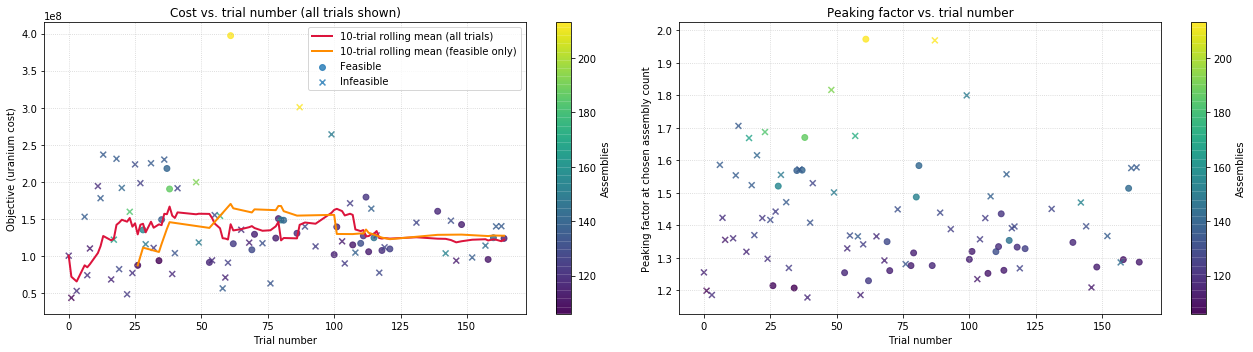

In [7]:
import optuna
import matplotlib.pyplot as plt

ASSEMBLY_PARAM = "N_sa"
PEAKING_MARGIN_ATTR = "peaking_margin"
ROLLING_WINDOW = 10
SHOW_ALL_TRIALS = True  # flip to False to show only feasible trials as dots


def is_feasible(t):
    constraints = t.system_attrs.get("constraints")
    if not constraints:
        return True
    return all(c <= 0.0 for c in constraints)


def extract_diagnostic_row(t):
    if t.state != optuna.trial.TrialState.COMPLETE or t.value is None:
        return None
    return {
        "number": t.number,
        "cost": t.value,
        "feasible": is_feasible(t),
        "assembly_count": t.params.get(ASSEMBLY_PARAM, t.user_attrs.get(ASSEMBLY_PARAM)),
        "peaking_margin": t.user_attrs.get("fpin_by_branch", {}).get("nominal"),
        "enrichment": t.params.get("fuel_enrichment"),
        "pin_radius": t.params.get("fuel_radius"),
    }


def build_diagnostic_table(study):
    """All completed trials, feasible and infeasible, each tagged with a 'feasible' flag."""
    rows = (extract_diagnostic_row(t) for t in study.trials)
    return [r for r in rows if r is not None]


def rolling_mean(numbers, values, window=ROLLING_WINDOW):
    paired = sorted(zip(numbers, values), key=lambda p: p[0])
    nums = [p[0] for p in paired]
    vals = [p[1] for p in paired]
    means = [sum(vals[max(0, i - window + 1): i + 1]) / len(vals[max(0, i - window + 1): i + 1])
             for i in range(len(vals))]
    return nums, means


def scatter_by_feasibility(ax, rows, color_by_assembly=True):
    """Plots feasible trials as filled circles, infeasible as hollow X's, coloured by assembly count."""
    feasible = [r for r in rows if r["feasible"]]
    infeasible = [r for r in rows if not r["feasible"]]

    def do_scatter(subset, marker, label):
        if not subset:
            return None
        x = [r["number"] for r in subset]
        y = [r["cost"] for r in subset]
        if color_by_assembly and any(r["assembly_count"] is not None for r in subset):
            c = [r["assembly_count"] if r["assembly_count"] is not None else 0 for r in subset]
            return ax.scatter(x, y, c=c, cmap="viridis", marker=marker, s=35, alpha=0.8, label=label)
        else:
            return ax.scatter(x, y, color="steelblue", marker=marker, s=35, alpha=0.8, label=label)

    sc_feasible = do_scatter(feasible, "o", "Feasible")
    do_scatter(infeasible, "x", "Infeasible")
    return sc_feasible  # used for the colorbar


def plot_all_diagnostics(rows, show_all=SHOW_ALL_TRIALS):
    if not rows:
        print("No completed trials found in study.")
        return

    display_rows = rows if show_all else [r for r in rows if r["feasible"]]
    fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(18, 5))

    # Plot 1: Cost over time — dots per current toggle, both rolling means always shown
    sc1 = scatter_by_feasibility(ax1, display_rows)
    if sc1 is not None:
        cbar1 = fig.colorbar(sc1, ax=ax1)
        cbar1.set_label("Assemblies")

    all_numbers = [r["number"] for r in rows]
    all_costs = [r["cost"] for r in rows]
    x_all, y_all = rolling_mean(all_numbers, all_costs)
    ax1.plot(x_all, y_all, color="crimson", linewidth=2,
              label=f"{ROLLING_WINDOW}-trial rolling mean (all trials)")

    feasible_rows = [r for r in rows if r["feasible"]]
    feasible_numbers = [r["number"] for r in feasible_rows]
    feasible_costs = [r["cost"] for r in feasible_rows]
    x_feas, y_feas = rolling_mean(feasible_numbers, feasible_costs)
    ax1.plot(x_feas, y_feas, color="darkorange", linewidth=2,
              label=f"{ROLLING_WINDOW}-trial rolling mean (feasible only)")

    ax1.legend()
    ax1.set_title(f"Cost vs. trial number ({'all trials' if show_all else 'feasible only'} shown)")
    ax1.set_xlabel("Trial number")
    ax1.set_ylabel("Objective (uranium cost)")
    ax1.grid(True, linestyle=":", alpha=0.6)

    # Plot 3: Peaking margin over time, respecting the same toggle
    margin_rows = [r for r in display_rows if r["peaking_margin"] is not None]
    if margin_rows:
        feasible_m = [r for r in margin_rows if r["feasible"]]
        infeasible_m = [r for r in margin_rows if not r["feasible"]]

        def do_margin_scatter(subset, marker):
            if not subset:
                return None
            x = [r["number"] for r in subset]
            y = [r["peaking_margin"] for r in subset]
            c = [r["assembly_count"] if r["assembly_count"] is not None else 0 for r in subset]
            return ax3.scatter(x, y, c=c, cmap="viridis", marker=marker, s=35, alpha=0.8)

        sc3 = do_margin_scatter(feasible_m, "o")
        do_margin_scatter(infeasible_m, "x")
        if sc3 is not None:
            cbar3 = fig.colorbar(sc3, ax=ax3)
            cbar3.set_label("Assemblies")
        ax3.set_title("Peaking factor vs. trial number")
        ax3.set_xlabel("Trial number")
        ax3.set_ylabel("Peaking factor at chosen assembly count")
        ax3.grid(True, linestyle=":", alpha=0.6)
    else:
        ax3.set_title("Continuous peaking margin vs. trial number")
        ax3.text(0.5, 0.5, f"No trials contain user_attr:\n'{PEAKING_MARGIN_ATTR}'",
                 ha="center", va="center", transform=ax3.transAxes, color="crimson")

    plt.tight_layout()
    plt.show()


rows = build_diagnostic_table(study)
plot_all_diagnostics(rows, show_all=SHOW_ALL_TRIALS)

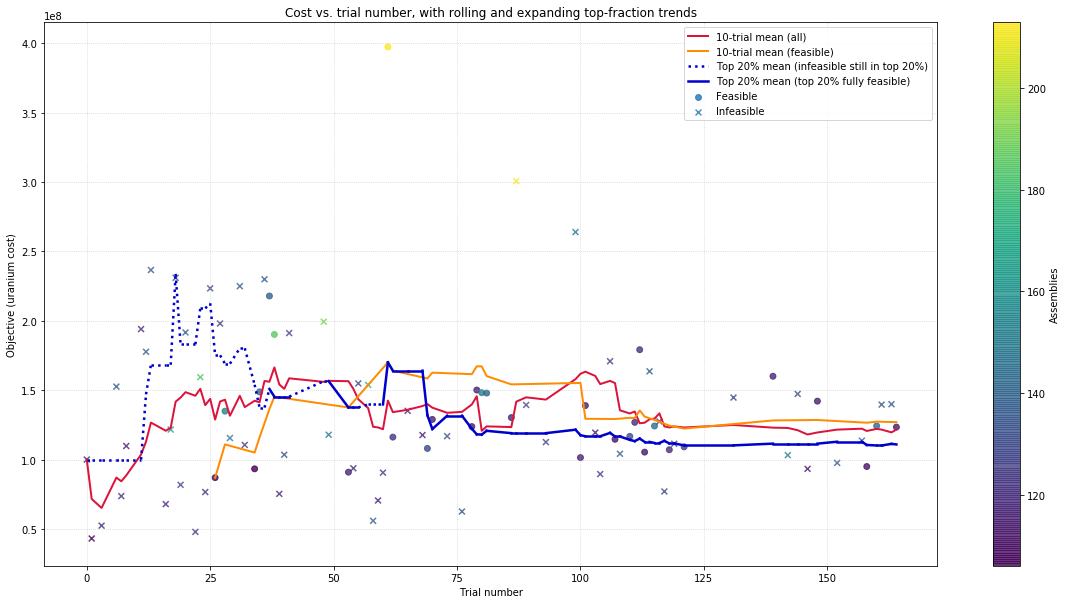

In [8]:
import optuna
import matplotlib.pyplot as plt

ASSEMBLY_PARAM = "N_sa"
ROLLING_WINDOW = 10       # window for the two existing mean lines
TOP_WINDOW = 50          # wider window for the top-20% line, so the subset isn't too small
TOP_FRACTION = 0.2
SHOW_ALL_TRIALS = True  

def total_violation(t):
    constraints = t.system_attrs.get("constraints")
    if not constraints:
        return 0.0
    return sum(max(0.0, c) for c in constraints)


def is_feasible(t):
    constraints = t.system_attrs.get("constraints")
    if not constraints:
        return True
    return all(c <= 0.0 for c in constraints)


def extract_row(t):
    if t.state != optuna.trial.TrialState.COMPLETE or t.value is None:
        return None
    return {
        "number": t.number,
        "cost": t.value,
        "feasible": is_feasible(t),
        "violation": total_violation(t),
        "assembly_count": t.params.get(ASSEMBLY_PARAM, t.user_attrs.get(ASSEMBLY_PARAM)),
    }


def build_rows(study):
    rows = (extract_row(t) for t in study.trials)
    return sorted((r for r in rows if r is not None), key=lambda r: r["number"])


def combined_rank(rows_so_far):
    """Feasible trials ranked by ascending cost; infeasible ranked after, by ascending violation."""
    feasible = sorted((r for r in rows_so_far if r["feasible"]), key=lambda r: r["cost"])
    infeasible = sorted((r for r in rows_so_far if not r["feasible"]), key=lambda r: r["violation"])
    return feasible + infeasible

def rolling_mean(numbers, values, window):
    means = [sum(values[max(0, i - window + 1): i + 1]) / len(values[max(0, i - window + 1): i + 1])
             for i in range(len(values))]
    return numbers, means


def expanding_top_fraction_mean(ordered_rows, fraction=TOP_FRACTION):
    numbers, means, mixed_flags = [], [], []
    seen = []
    for row in ordered_rows:
        seen.append(row)
        ranked = combined_rank(seen)
        top_n = max(1, round(len(ranked) * fraction))
        top_rows = ranked[:top_n]
        numbers.append(row["number"])
        means.append(sum(r["cost"] for r in top_rows) / len(top_rows))
        mixed_flags.append(any(not r["feasible"] for r in top_rows))
    return numbers, means, mixed_flags


def plot_segmented_line(ax, x, y, mixed_flags, color, base_label):
    labelled_solid = labelled_dashed = False
    for i in range(len(x) - 1):
        dashed = mixed_flags[i + 1]  # style reflects the group composition at the segment's end point
        label = None
        if dashed and not labelled_dashed:
            label = f"{base_label} (infeasible still in top 20%)"
            labelled_dashed = True
        elif not dashed and not labelled_solid:
            label = f"{base_label} (top 20% fully feasible)"
            labelled_solid = True
        ax.plot(x[i:i + 2], y[i:i + 2], linestyle="dotted" if dashed else "-",
                 color=color, linewidth=2.5, label=label)


rows = build_rows(study)
all_numbers = [r["number"] for r in rows]
all_costs = [r["cost"] for r in rows]
feasible_rows = [r for r in rows if r["feasible"]]
feasible_numbers = [r["number"] for r in feasible_rows]
feasible_costs = [r["cost"] for r in feasible_rows]

x_all, y_all = rolling_mean(all_numbers, all_costs, ROLLING_WINDOW)
x_feas, y_feas = rolling_mean(feasible_numbers, feasible_costs, ROLLING_WINDOW)
x_top, y_top, mixed_flags = expanding_top_fraction_mean(rows)
display_rows = rows if SHOW_ALL_TRIALS else [r for r in rows if r["feasible"]]

fig, ax = plt.subplots(figsize=(20, 10))
sc = scatter_by_feasibility(ax, display_rows)
if sc is not None:
    cbar1 = fig.colorbar(sc, ax=ax)
    cbar1.set_label("Assemblies")

ax.plot(x_all, y_all, color="crimson", linewidth=2, label=f"{ROLLING_WINDOW}-trial mean (all)")
ax.plot(x_feas, y_feas, color="darkorange", linewidth=2, label=f"{ROLLING_WINDOW}-trial mean (feasible)")
plot_segmented_line(ax, x_top, y_top, mixed_flags, color="mediumblue", base_label="Top 20% mean")

ax.legend()
ax.set_title("Cost vs. trial number, with rolling and expanding top-fraction trends")
ax.set_xlabel("Trial number")
ax.set_ylabel("Objective (uranium cost)")
ax.grid(True, linestyle=":", alpha=0.6)
# plt.tight_layout()
plt.show()

<ipython-input-23-27b11985102a>:14: ExperimentalWarning: PedAnovaImportanceEvaluator is experimental (supported from v3.6.0). The interface can change in the future.
  study, evaluator=PedAnovaImportanceEvaluator(baseline_quantile=0.2)


Parameter                            fANOVA    PED-ANOVA
fuel_enrichment                      0.9983       0.7243
fuel_radius                          0.0000       0.0082
gd_axis_w_0                          0.0000       0.0243
gd_axis_w_1                          0.0004       0.0348
gd_axis_w_2                          0.0003       0.0145
gd_axis_w_3                          0.0001       0.0049
gd_conc                              0.0004       0.0046
gd_interior_w_0                      0.0000       0.0036
gd_interior_w_1                      0.0000       0.0074
gd_interior_w_2                      0.0000       0.0163
gd_interior_w_3                      0.0000       0.0174
gt_axis_w_0                          0.0000       0.0082
gt_axis_w_1                          0.0002       0.0283
gt_axis_w_2                          0.0000       0.0102
gt_axis_w_3                          0.0000       0.0087
gt_interior_w_0                      0.0000       0.0010
gt_interior_w_1                

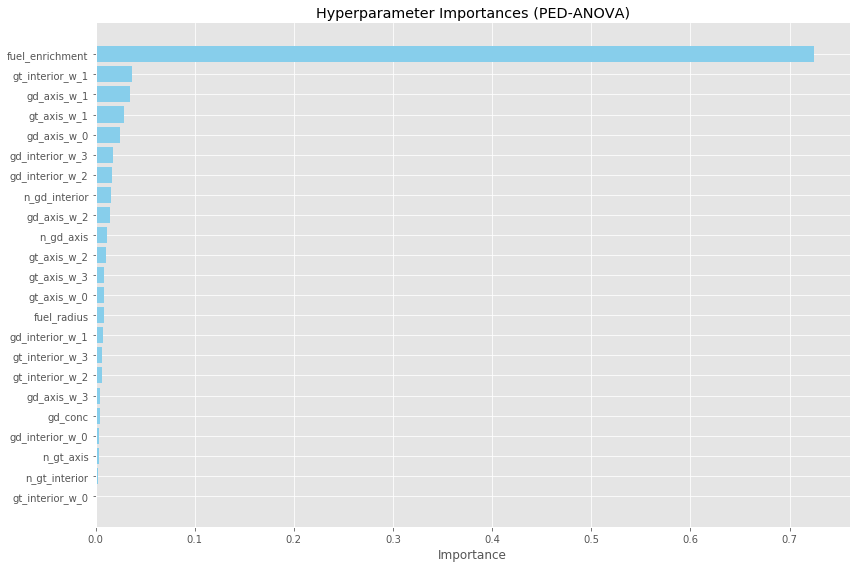

In [ ]:
import matplotlib.pyplot as plt
import optuna
from optuna.importance import (
    FanovaImportanceEvaluator,
    PedAnovaImportanceEvaluator,
)


def compare_importance_methods(study):
    fanova = optuna.importance.get_param_importances(
        study, evaluator=FanovaImportanceEvaluator()
    )
    ped_anova = optuna.importance.get_param_importances(
        study, evaluator=PedAnovaImportanceEvaluator(baseline_quantile=0.2)
    )
    all_params = sorted(set(fanova) | set(ped_anova))
    print(f"{'Parameter':<30} {'fANOVA':>12} {'PED-ANOVA':>12}")
    for p in all_params:
        print(
            f"{p:<30} {fanova.get(p, 0.0):>12.4f} {ped_anova.get(p, 0.0):>12.4f}"
        )
    return fanova, ped_anova

fanova, ped_anova = compare_importance_methods(study)

# Custom Bar Plot
sorted_params = dict(sorted(ped_anova.items(), key=lambda item: item[1]))

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(
    list(sorted_params.keys()), list(sorted_params.values()), color="skyblue"
)
ax.set_xlabel("Importance")
ax.set_title("Hyperparameter Importances (PED-ANOVA)")

# Compatible with all Matplotlib versions
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

<ipython-input-21-54c0e63ec65f>:7: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  plot_slice(study, params=inert_candidate_params)


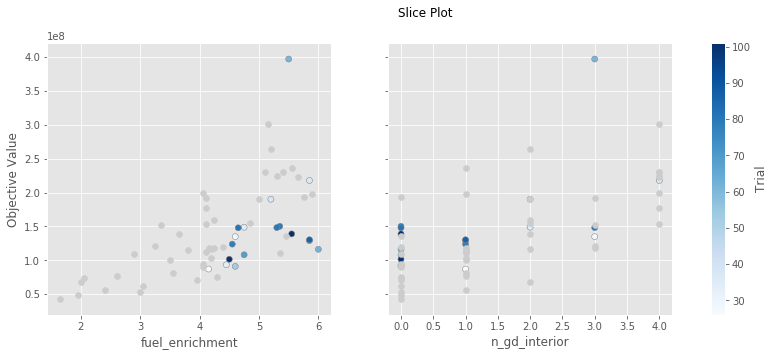

<ipython-input-21-54c0e63ec65f>:13: ExperimentalWarning: optuna.visualization.matplotlib._rank.plot_rank is experimental (supported from v3.2.0). The interface can change in the future.
  plot_rank(study, params=inert_candidate_params)


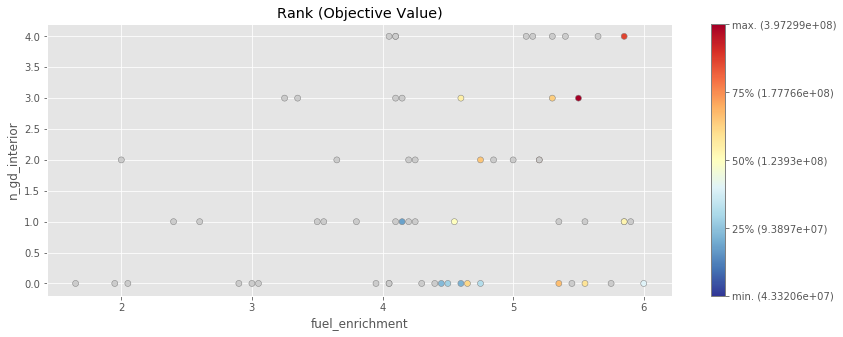

In [21]:
import matplotlib.pyplot as plt
from optuna.visualization.matplotlib import plot_rank, plot_slice

inert_candidate_params = [ "fuel_enrichment","n_gd_interior"]

# Slice Plot
plot_slice(study, params=inert_candidate_params)
plt.gcf().set_size_inches(14, 5)  # 14 inches wide, 5 inches high
# plt.tight_layout()
plt.show()

# Rank Plot
plot_rank(study, params=inert_candidate_params)
plt.gcf().set_size_inches(14, 5)  # 14 inches wide, 5 inches high
# plt.tight_layout()
plt.show()

In [8]:
test_trial =study.trials[244]
print(f"=== Trial #{test_trial.number} Information ===")
print(f"State:               {test_trial.state.name}")
print(f"Value (Objective):   {test_trial.value}")          # Use trial.values for multi-objective
print(f"Parameters:          {test_trial.params}")
print(f"User Attributes:     {test_trial.user_attrs}")
print(f"System Attributes:   {test_trial.system_attrs}")
print(f"Intermediate Values: {test_trial.intermediate_values}")
print(f"Start Time:          {test_trial.datetime_start}")
print(f"Complete Time:       {test_trial.datetime_complete}")
print(f"Duration:            {test_trial.duration}")


=== Trial #244 Information ===
State:               COMPLETE
Value (Objective):   3.05
Parameters:          {'fuel_enrichment': 3.0500000000000003, 'gd_conc': 0.4, 'fuel_radius': 0.41, 'n_gt_axis': 3, 'n_gt_interior': 2, 'n_gd_axis': 1, 'n_gd_interior': 3, 'gd_axis_w_0': 0.868427729152356, 'gd_axis_w_1': 0.16298524337068387, 'gd_axis_w_2': 0.3247570207240551, 'gd_axis_w_3': 0.7713222764378502, 'gt_axis_w_0': 0.19782092044642918, 'gt_axis_w_1': 0.32701207665741905, 'gt_axis_w_2': 0.06316541359293347, 'gt_axis_w_3': 0.7949085432958658, 'gd_interior_w_0': 0.6639559002883689, 'gd_interior_w_1': 0.26349866111346953, 'gd_interior_w_2': 0.9458431996647807, 'gd_interior_w_3': 0.060452432153027945, 'gt_interior_w_0': 0.8068305054465468, 'gt_interior_w_1': 0.2888052659154882, 'gt_interior_w_2': 0.8727518804979679, 'gt_interior_w_3': 0.9037424475504163}
User Attributes:     {'branch_keff': {'nominal': [1.32236, 1.26653, 1.22616, 1.09402, 1.00614, 0.852373, 0.792188], 'hfp_mtc': [1.31502, 1.25417,

In [68]:

from pathlib import Path
res_paths= [
    # Path("/home/gtl23/optimisation/BA_opti/geom_opti_12/10_fU5.000_gU1.375_gd11.700_Ur_0.500_geo_gd36_(4,4)_(1,5)_(3,5)_(3,7)_(4,8)_gt32_(0,1)_(3,3)_(2,7)_(5,7)_(7,8)_B4C/10_fU5.000_gU1.375_gd11.700_Ur_0.500_geo_gd36_(4,4)_(1,5)_(3,5)_(3,7)_(4,8)_gt32_(0,1)_(3,3)_(2,7)_(5,7)_(7,8)_B4C_res.m")
    # Path("/home/gtl23/optimisation/BA_opti/geom_opti_8/1_precise_run3/1_fU3.000_gU0.250_gd8.000_Ur_0.450_geo_gd16_(2,2)_(6,6)_(2,7)_gt24_(0,3)_(3,3)_(5,5)_(0,6)_(3,6)_B4C_res.m"),
    # Path("/home/gtl23/optimisation/BA_opti/geom_opti_8/1_precise_run/1_fU3.000_gU0.250_gd8.000_Ur_0.450_geo_gd16_(2,2)_(6,6)_(2,7)_gt24_(0,3)_(3,3)_(5,5)_(0,6)_(3,6)_B4C_res.m"),
    # Path("/home/gtl23/optimisation/BA_opti/geom_opti_3/50_geo_total_28_out(2, 2)_int(1, 7)_(3, 7)_(6, 7)_B4C_fU3.150_gU0.350_gd4.000_Ur_0.460/50_geo_total_28_out(2, 2)_int(1, 7)_(3, 7)_(6, 7)_B4C_fU3.150_gU0.350_gd4.000_Ur_0.460_res.m")
            # Path("/home/gtl23/optimisation/BA_opti/BA_test_case3/1_pwr17_layout1_B4C_fU3.000_gU0.250_gd8.000/1_pwr17_layout1_B4C_fU3.000_gU0.250_gd8.000_res.m"),
# Path("/home/gtl23/optimisation/BA_opti/geom_opti_8/1_fU3.000_gU0.250_gd8.000_Ur_0.450_geo_gd16_(2,2)_(6,6)_(2,7)_gt24_(0,3)_(3,3)_(5,5)_(0,6)_(3,6)_B4C/1_fU3.000_gU0.250_gd8.000_Ur_0.450_geo_gd16_(2,2)_(6,6)_(2,7)_gt24_(0,3)_(3,3)_(5,5)_(0,6)_(3,6)_B4C_res.m"),
# Path("/home/gtl23/optimisation/BA_opti/geom_opti_13/171_fU2.900_gU1.775_gd7.700_Ur_0.420_geo_gd28_(0,3)_(5,5)_(0,8)_(1,6)_(5,8)_gt24_(0,5)_(7,7)_(3,5)_(3,6)_B4C/171_fU2.900_gU1.775_gd7.700_Ur_0.420_geo_gd28_(0,3)_(5,5)_(0,8)_(1,6)_(5,8)_gt24_(0,5)_(7,7)_(3,5)_(3,6)_B4C_res.m"),
# Path("/home/gtl23/optimisation/BA_opti/geom_opti_14/64_fU3.150_gU1.625_gd8.600_Ur_0.410_geo_gd8__(2,4)_gt28_(0,6)_(4,6)_(2,8)_(5,8)_B4C/64_fU3.150_gU1.625_gd8.600_Ur_0.410_geo_gd8__(2,4)_gt28_(0,6)_(4,6)_(2,8)_(5,8)_B4C_res.m"),
# Path("/home/gtl23/optimisation/BA_opti/geom_opti_14/244_fU3.050_gU0.000_gd0.000_Ur_0.410_geo_gd28_(7,7)_(1,5)_(4,7)_(6,8)_gt28_(0,1)_(2,2)_(0,4)_(2,5)_(2,8)_B4C/244_fU3.050_gU0.000_gd0.000_Ur_0.410_geo_gd28_(7,7)_(1,5)_(4,7)_(6,8)_gt28_(0,1)_(2,2)_(0,4)_(2,5)_(2,8)_B4C_res.m"),
# Path("/home/gtl23/optimisation/BA_opti/geom_opti_14/64_fU3.150_gU1.625_gd8.600_Ur_0.410_geo_gd8__(2,4)_gt28_(0,6)_(4,6)_(2,8)_(5,8)_B4C/64_fU3.150_gU1.625_gd8.600_Ur_0.410_geo_gd8__(2,4)_gt28_(0,6)_(4,6)_(2,8)_(5,8)_B4C_res.m"),
# Path("/home/gtl23/optimisation/BA_opti/geom_opti_15/120_fU3.150_gU1.325_gd8.200_Ur_0.400_geo_gd16_(3,3)_(4,4)_(0,7)_(7,7)__gt32__(3,4)_(1,5)_(5,6)_(6,7)_B4C/120_fU3.150_gU1.325_gd8.200_Ur_0.400_geo_gd16_(3,3)_(4,4)_(0,7)_(7,7)__gt32__(3,4)_(1,5)_(5,6)_(6,7)_B4C_res.m")
Path("/home/gtl23/optimisation/BA_opti/Final_code/geom_opti_TH_12/53_fU4.600_gU0.000_gd0.000_Ur_0.370_geo_gd0___gt32_(1,1)_(0,4)_(4,4)_(5,5)_(3,5)_(1,7)_B4C/53_fU4.600_gU0.000_gd0.000_Ur_0.370_geo_gd0___gt32_(1,1)_(0,4)_(4,4)_(5,5)_(3,5)_(1,7)_B4C_res.m")
]
root_dir = Path.cwd()
from utils import parse_branches_inc
from utils import fetch_full_results

In [ ]:
fetch_full_results(
    Path("/home/gtl23/optimisation/BA_opti/geom_opti_3/3_geo_total_16_out(2, 2)_(6, 6)_int(2, 7)_B4C_fU1.150_gU0.000_gd0.000_Ur_0.450/3_geo_total_16_out(2, 2)_(6, 6)_int(2, 7)_B4C_fU1.150_gU0.000_gd0.000_Ur_0.450"),
    n_nominal_steps=5,
)


In [69]:
import pandas as pd
import numpy as np
import serpentTools

results = []

for res_path in res_paths:
    try:
        res = serpentTools.read(str(res_path))
        rel_folder = res_path.parent.relative_to(root_dir)

        # 1. Parse branch file for burnup points
        inc_path = res_path.parent / "branches.inc"
        if not inc_path.exists():
            inc_files = list(res_path.parent.glob("*.inc"))
            inc_path = inc_files[0] if inc_files else None

        if inc_path and inc_path.exists():
            b_info = parse_branches_inc(inc_path)
            n_burnup = b_info["n_burnup"]
            branch_order = b_info["branch_order"]
            burnup_points = b_info.get("burnup_points", [])
        else:
            n_burnup = None
            branch_order = []
            burnup_points = []

        # 2. Extract keff, burnup, and burn days safely
        abs_keff = res.resdata.get("absKeff")
        print(np.shape(abs_keff))

        burnup_raw = res.resdata.get("burnup")
        if burnup_raw is None:
            burnup_raw = res.resdata.get("burnUp")

        burn_days_raw = res.resdata.get("burnDays")

        if abs_keff is not None:

            def get_burnup(b_step_idx):
                if burnup_raw is not None and b_step_idx < len(burnup_raw):
                    val = burnup_raw[b_step_idx]
                    return val[0] if hasattr(val, "__len__") else float(val)
                elif burnup_points and b_step_idx < len(burnup_points):
                    return burnup_points[b_step_idx]
                return 0.0

            def get_days(b_step_idx):
                if burn_days_raw is not None and b_step_idx < len(burn_days_raw):
                    val = burn_days_raw[b_step_idx]
                    return val[0] if hasattr(val, "__len__") else float(val)
                return 0.0

            total_blocks = len(abs_keff) // n_burnup if (n_burnup and n_burnup > 0) else 1

            for step_idx, (keff_val, keff_sd) in enumerate(abs_keff):
                if n_burnup and n_burnup > 0:
                    block_idx = step_idx // n_burnup  # Evaluates to 0, 1, 2, 3, 4
                    b_step = step_idx % n_burnup  # Evaluates to 0, 1, 2, 3, 4

                    # Case A: branch_order already includes 'nominal' (e.g., 5 branches for 5 blocks)
                    if len(branch_order) == total_blocks:
                        branch_name = branch_order[block_idx]

                    # Case B: branch_order only contains off-nominal branches (e.g., 4 branches + 1 nominal)
                    else:
                        if block_idx == 0:
                            branch_name = "nominal"
                        else:
                            b_idx = block_idx - 1
                            branch_name = (
                                branch_order[b_idx]
                                if b_idx < len(branch_order)
                                else f"branch_{b_idx}"
                            )

                    bu_val = get_burnup(b_step)
                    days_val = get_days(b_step)
                else:
                    branch_name = "nominal"
                    b_step = step_idx
                    bu_val = get_burnup(step_idx)
                    days_val = get_days(step_idx)

                results.append(
                    {
                        "Case Folder": str(rel_folder),
                        "File": res_path.name,
                        "Branch": branch_name,
                        "Burnup Step": b_step,
                        "Burnup": bu_val,
                        "Burn Days": days_val,
                        "absKeff": keff_val,
                        "Std Dev": keff_sd,
                    }
                )

    except Exception as e:
        print(f"Error reading {res_path.name}: {e}")

df = pd.DataFrame(results)
print(df)
print(burnup_points)

(35, 2)
                                          Case Folder  \
0   geom_opti_TH_12/53_fU4.600_gU0.000_gd0.000_Ur_...   
1   geom_opti_TH_12/53_fU4.600_gU0.000_gd0.000_Ur_...   
2   geom_opti_TH_12/53_fU4.600_gU0.000_gd0.000_Ur_...   
3   geom_opti_TH_12/53_fU4.600_gU0.000_gd0.000_Ur_...   
4   geom_opti_TH_12/53_fU4.600_gU0.000_gd0.000_Ur_...   
5   geom_opti_TH_12/53_fU4.600_gU0.000_gd0.000_Ur_...   
6   geom_opti_TH_12/53_fU4.600_gU0.000_gd0.000_Ur_...   
7   geom_opti_TH_12/53_fU4.600_gU0.000_gd0.000_Ur_...   
8   geom_opti_TH_12/53_fU4.600_gU0.000_gd0.000_Ur_...   
9   geom_opti_TH_12/53_fU4.600_gU0.000_gd0.000_Ur_...   
10  geom_opti_TH_12/53_fU4.600_gU0.000_gd0.000_Ur_...   
11  geom_opti_TH_12/53_fU4.600_gU0.000_gd0.000_Ur_...   
12  geom_opti_TH_12/53_fU4.600_gU0.000_gd0.000_Ur_...   
13  geom_opti_TH_12/53_fU4.600_gU0.000_gd0.000_Ur_...   
14  geom_opti_TH_12/53_fU4.600_gU0.000_gd0.000_Ur_...   
15  geom_opti_TH_12/53_fU4.600_gU0.000_gd0.000_Ur_...   
16  geom_opti_TH_12/53_

hfp_mtc
7     1.460650
8     1.359680
9     1.324940
10    1.213330
11    1.114430
12    1.027570
13    0.830403
Name: absKeff, dtype: float64
hzp_base
14    1.484840
15    1.429720
16    1.393960
17    1.277840
18    1.174310
19    1.077680
20    0.864756
Name: absKeff, dtype: float64
hzp_mtc
21    1.470760
22    1.418480
23    1.384260
24    1.265010
25    1.158590
26    1.063700
27    0.852773
Name: absKeff, dtype: float64
nominal
0    1.466720
1    1.371050
2    1.337510
3    1.228210
4    1.126610
5    1.030710
6    0.832412
Name: absKeff, dtype: float64
rodIn_cold
28    0.864360
29    0.836801
30    0.822276
31    0.746999
32    0.679079
33    0.607538
34    0.461561
Name: absKeff, dtype: float64


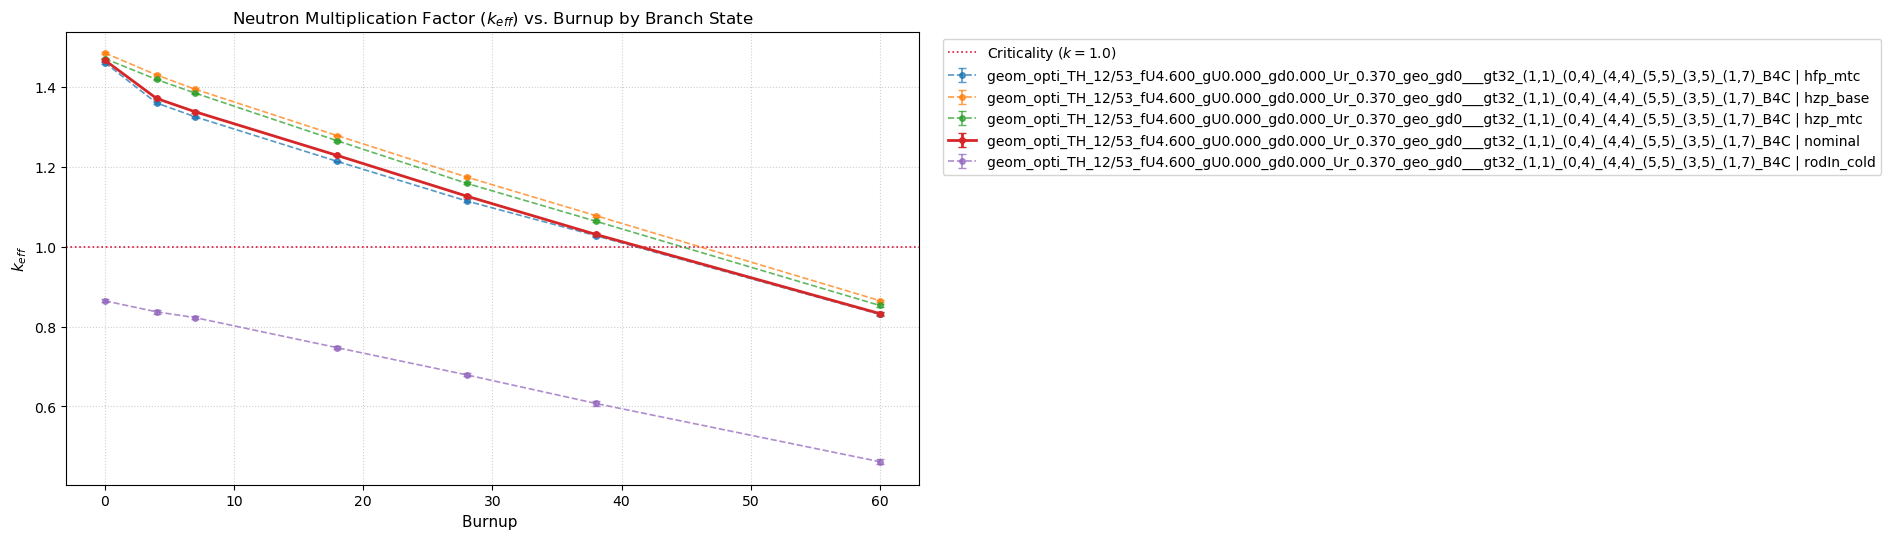

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6), dpi=100)

# Group by Case and Branch to draw distinct curves
for (case_name, branch_name), group in df.groupby(["Case Folder", "Branch"]):
    # if branch_name != "hfp_mtc" and branch_name != "nominal":
    #     continue
    group_sorted = group.sort_values("Burnup Step")
    print(branch_name)
    print(group_sorted["absKeff"])

    is_nominal = branch_name == "nominal"
    linestyle = "-" if is_nominal else "--"
    linewidth = 2.0 if is_nominal else 1.2
    alpha = 1.0 if is_nominal else 0.75

    plt.errorbar(
        group_sorted["Burnup"],
        group_sorted["absKeff"],
        yerr=group_sorted["Std Dev"],
        fmt="o" + linestyle,
        linewidth=linewidth,
        alpha=alpha,
        markersize=4,
        capsize=3,
        label=f"{case_name} | {branch_name}",
    )

plt.axhline(
    1.0,
    color="crimson",
    linestyle=":",
    linewidth=1.2,
    label="Criticality ($k=1.0$)",
)
plt.xlabel("Burnup ", fontsize=11)
plt.ylabel("$k_{eff}$", fontsize=11)
plt.title(
    "Neutron Multiplication Factor ($k_{eff}$) vs. Burnup by Branch State",
    fontsize=12,
    # pad=12,
)
plt.grid(True, linestyle=":", alpha=0.6)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.show()

In [30]:
from pathlib import Path
import re
from typing import Any, Dict, List, Optional, Union
import numpy as np
import pandas as pd
import serpentTools as st

# Configure pandas to show full filenames without truncation (...)
# Configure pandas to show full filenames without truncation
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 1000)
pd.set_option("display.width", 1000)


def resolve_branch_name(
    b_str: Optional[str],
    branch_order: Optional[List[str]] = None,
    base_name: str = "nominal_base",
) -> str:
    """Maps Serpent branch tag string ('1'..'5') or None to a branch name.

    - None (e.g. det1.m) -> base_name ('nominal_base')
    - '1' (e.g. det1b1.m) -> branch_order[0] ('nominal')
    - '2' (e.g. det1b2.m) -> branch_order[1] ('hfp_mtc')
    """
    if b_str is None:
        return base_name

    if not branch_order:
        return f"branch_{b_str}"

    b_num = int(b_str)  # 1-based index from Serpent (b1=1, b2=2, ...)
    b_idx = b_num - 1  # 0-based index for python list

    if 0 <= b_idx < len(branch_order):
        return branch_order[b_idx]

    return f"branch_{b_num}"


def parse_serpent_filename(f_path: Path, branch_order: Optional[List[str]] = None):
    """Parses filename (e.g. ..._det0.m, ..._det1b1.m) into (step, branch_name, sorting_key)."""
    match = re.search(r"det(\d+)(?:_?b(\d+))?\.m$", f_path.name, re.IGNORECASE)
    if not match:
        return None, f_path.stem, (9999, 9999)

    step = int(match.group(1))
    b_str = match.group(2)

    branch_name = resolve_branch_name(b_str, branch_order)
    b_num = int(b_str) if b_str is not None else 0
    sort_key = (step, b_num)

    return step, branch_name, sort_key


def extract_2d_detector_df(
    det_file: Union[str, Path],
    target_det_name: str,
    case_name: str = "case1",
    branch_name: Optional[str] = None,
    case_params: Optional[Dict[str, Any]] = None,
    branch_order: Optional[List[str]] = None,
) -> pd.DataFrame:
    """Extracts 2D detector tallies from a Serpent detector file into a Pandas DataFrame."""
    det_file = Path(det_file)
    case_params = case_params or {}

    if branch_name is None:
        _, branch_name, _ = parse_serpent_filename(det_file, branch_order)

    det_data = st.read(str(det_file), reader="det")
    if target_det_name not in det_data.detectors:
        raise KeyError(
            f"Detector '{target_det_name}' not found in {det_file.name}. "
            f"Available detectors: {list(det_data.detectors.keys())}"
        )

    detector = det_data.detectors[target_det_name]
    tallies = detector.tallies
    errors = detector.errors
    grids = detector.grids

    shape = tallies.shape
    mesh_indices = np.indices(shape)

    data = {
        "case_name": case_name,
        "branch": branch_name,
        "det_file": det_file.name,
        "detector": target_det_name,
        "tally": tallies.ravel(),
        "rel_err": errors.ravel(),
        "sd": (tallies * errors).ravel(),
    }
    data.update(case_params)

    for dim_i, (g_name, g_vals) in enumerate(grids.items()):
        if dim_i < len(shape):
            idx_flat = mesh_indices[dim_i].ravel()
            data[f"bin_{g_name}_idx"] = idx_flat

            g_arr = np.asarray(g_vals)

            if g_arr.ndim == 2:
                cols = g_arr.shape[1]
                if cols >= 2:
                    data[f"bin_{g_name}_min"] = g_arr[idx_flat, 0]
                    data[f"bin_{g_name}_max"] = g_arr[idx_flat, 1]
                if cols >= 3:
                    data[f"bin_{g_name}_mid"] = g_arr[idx_flat, 2]
                elif cols == 2:
                    data[f"bin_{g_name}_mid"] = 0.5 * (
                        g_arr[idx_flat, 0] + g_arr[idx_flat, 1]
                    )
                elif cols == 1:
                    data[f"bin_{g_name}_mid"] = g_arr[idx_flat, 0]

            elif g_arr.ndim == 1:
                dim_len = shape[dim_i]
                if len(g_arr) == dim_len + 1:
                    mids = 0.5 * (g_arr[:-1] + g_arr[1:])
                    data[f"bin_{g_name}_min"] = g_arr[:-1][idx_flat]
                    data[f"bin_{g_name}_max"] = g_arr[1:][idx_flat]
                    data[f"bin_{g_name}_mid"] = mids[idx_flat]
                    data[f"bin_{g_name}_width"] = np.diff(g_arr)[idx_flat]
                elif len(g_arr) == dim_len:
                    data[f"bin_{g_name}_mid"] = g_arr[idx_flat]

    return pd.DataFrame(data)


def calculate_2d_pin_peaking(
    df: pd.DataFrame,
    x_col: str = "bin_X_idx",
    y_col: str = "bin_Y_idx",
    zero_threshold: float = 1e-12,
) -> Dict[str, Any]:
    """Calculates the 2D Pin Power Peaking Factor F_pin (F_xy) and identifies hot pin location."""
    active_fuel_df = df[df["tally"] > zero_threshold].copy()

    if active_fuel_df.empty:
        raise ValueError("No positive detector tallies found above zero_threshold.")

    if x_col in active_fuel_df.columns and y_col in active_fuel_df.columns:
        pin_powers = (
            active_fuel_df.groupby([x_col, y_col], as_index=False)["tally"].sum()
        )
    else:
        pin_powers = active_fuel_df

    p_max = float(pin_powers["tally"].max())
    p_avg = float(pin_powers["tally"].mean())
    f_pin = p_max / p_avg if p_avg > 0 else 0.0

    hot_pin_idx = pin_powers["tally"].idxmax()
    hot_pin_location = pin_powers.loc[hot_pin_idx].to_dict()

    return {
        "F_pin": f_pin,
        "P_max": p_max,
        "P_avg": p_avg,
        "hot_pin_location": hot_pin_location,
        "active_pins_count": len(pin_powers),
    }


# ==========================================
# Execution Configuration
# ==========================================

base_path = Path(
"/home/gtl23/optimisation/BA_opti/Final_code/geom_opti_TH_12/28_fU4.600_gU1.025_gd11.900_Ur_0.400_geo_gd32_(3,3)_(0,5)_(1,3)_(4,5)_(4,7)_gt44_(1,1)_(0,6)_(8,8)_(3,4)_(3,7)_(3,8)_(5,8)_B4C/28_fU4.600_gU1.025_gd11.900_Ur_0.400_geo_gd32_(3,3)_(0,5)_(1,3)_(4,5)_(4,7)_gt44_(1,1)_(0,6)_(8,8)_(3,4)_(3,7)_(3,8)_(5,8)_B4C")
case_dir = base_path.parent
case_name = base_path.name
target_det_name = "pinpowers"

# 5 branches matching b1, b2, b3, b4, b5 exactly
branch_order = ["nominal", "hfp_mtc", "hzp_base", "hzp_mtc", "rodIn_cold"]

# 1. Parse burnup values from res file safely
burnup_map = {}
res_files = list(case_dir.glob("*_res.m"))
if res_files:
    try:
        res = st.read(str(res_files[0]))
        bu_data = res.resdata.get("burnup", res.resdata.get("burnUp"))
        if bu_data is not None:
            bu_arr = np.asarray(bu_data)
            for step_idx in range(len(bu_arr)):
                val = bu_arr[step_idx][0] if bu_arr.ndim == 2 else bu_arr[step_idx]
                burnup_map[step_idx] = float(val)
    except Exception as e:
        print(f"[INFO] Could not parse burnup values from {res_files[0].name}: {e}")

# 2. Discover and sort detector files chronologically
all_det_files = [
    f for f in case_dir.glob("*_det*.m") if not f.name.endswith("_dep.m")
]

parsed_files = []
for f in all_det_files:
    step, branch, sort_key = parse_serpent_filename(f, branch_order)
    if step is not None:
        parsed_files.append((f, step, branch, sort_key))

parsed_files.sort(key=lambda item: item[3])

print(
    f"Found {len(parsed_files)} detector file(s) across {len(set(s[1] for s in parsed_files))} burnup step(s) in: {case_dir.name}\n"
)

# 3. Processing Loop
branch_results = []

for det_file, step, branch_name, _ in parsed_files:
    try:
        df_det = extract_2d_detector_df(
            det_file=det_file,
            target_det_name=target_det_name,
            case_name=case_name,
            branch_name=branch_name,
            branch_order=branch_order,
        )

        peaking_res = calculate_2d_pin_peaking(df_det)
        hot_loc = peaking_res["hot_pin_location"]

        branch_results.append(
            {
                "Burnup_Step": step,
                "Burnup_MWd_kgU": burnup_map.get(step, "N/A"),
                "Branch": branch_name,
                "F_pin": peaking_res["F_pin"],
                "P_max": peaking_res["P_max"],
                "P_avg": peaking_res["P_avg"],
                "Hot_Pin_X": hot_loc.get("bin_X_idx", "N/A"),
                "Hot_Pin_Y": hot_loc.get("bin_Y_idx", "N/A"),
                "Active_Pins": peaking_res["active_pins_count"],
                "File": det_file.name,
            }
        )
    except Exception as e:
        print(f"[SKIP] Failed processing {det_file.name}: {e}")

# 4. Display Summary Table
summary_df = pd.DataFrame(branch_results)

if summary_df.empty:
    print(
        "[WARNING] No detector files were successfully processed. Check target detector name."
    )
else:
    print("=" * 115)
    print(f" PEAKING SUMMARY FOR CASE: {case_name}")
    print("=" * 115)
    cols_to_print = [
        "Burnup_Step",
        "Burnup_MWd_kgU",
        "Branch",
        "F_pin",
        "P_max",
        "P_avg",
        "Hot_Pin_X",
        "Hot_Pin_Y",
        "File",
    ]
    print(summary_df[cols_to_print].to_string(index=False))

Found 50 detector file(s) across 15 burnup step(s) in: 28_fU4.600_gU1.025_gd11.900_Ur_0.400_geo_gd32_(3,3)_(0,5)_(1,3)_(4,5)_(4,7)_gt44_(1,1)_(0,6)_(8,8)_(3,4)_(3,7)_(3,8)_(5,8)_B4C

 PEAKING SUMMARY FOR CASE: 28_fU4.600_gU1.025_gd11.900_Ur_0.400_geo_gd32_(3,3)_(0,5)_(1,3)_(4,5)_(4,7)_gt44_(1,1)_(0,6)_(8,8)_(3,4)_(3,7)_(3,8)_(5,8)_B4C
 Burnup_Step  Burnup_MWd_kgU        Branch     F_pin    P_max       P_avg  Hot_Pin_X  Hot_Pin_Y                                                                                                                                     File
           0             0.0  nominal_base  1.501912  245.393  163.387030       16.0       12.0    28_fU4.600_gU1.025_gd11.900_Ur_0.400_geo_gd32_(3,3)_(0,5)_(1,3)_(4,5)_(4,7)_gt44_(1,1)_(0,6)_(8,8)_(3,4)_(3,7)_(3,8)_(5,8)_B4C_det0.m
           1             4.0  nominal_base  1.487950  244.199  164.117699        4.0        0.0    28_fU4.600_gU1.025_gd11.900_Ur_0.400_geo_gd32_(3,3)_(0,5)_(1,3)_(4,5)_(4,7)_gt44_(1,1)_(0,6)_(8,8)

In [32]:
from __future__ import annotations
from pathlib import Path
import re
from typing import Any, Dict, List, Optional, Tuple, Union
import numpy as np
import pandas as pd
import serpentTools as st

# Configure pandas column formatting
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 1000)
pd.set_option("display.width", 1000)

# ==============================================================================
# USER CONFIGURATION (Set your 10 exact nominal step burnups here)
# ==============================================================================

# Burnup for each nominal step (det0.m through det9.m)
# Edit these 10 values to match your exact nominal depletion schedule!
nominal_step_burnups = [
    0.1,  # det0.m
    1.0,  # det1.m
    4.0,  # det2.m
    9.0,  # det3.m
    16.0,  # det4.m  <-- Step 4 (16.0 MWd/kgU)
    22.0,  # det5.m
    30.0,  # det6.m
    38.0,  # det7.m
    48.0,  # det8.m
    60.0,  # det9.m
]

# Target burnups for the 5 coefficient points (det1b* through det5b*)
coef_burnups = {
    1: 0.1,  # det1b1..det1b5
    2: 7.0,  # det2b1..det2b5
    3: 22.0,  # det3b1..det3b5
    4: 38.0,  # det4b1..det4b5
    5: 60.0,  # det5b1..det5b5
}

# Branch order corresponding to b1..b5 suffixes
branch_order = ["nominal", "hfp_mtc", "hzp_base", "hzp_mtc", "rodIn_cold"]

# ==============================================================================
# FILE PARSER & CALCULATIONS
# ==============================================================================


def parse_detector_filename(
    f_path: Path,
) -> Tuple[int, float, str, bool, Optional[int]]:
  """Parses Serpent detector filename structure:

  - detN.m   -> Nominal step N (0..9)
  - detXbY.m -> Coef point X (1..5), Branch Y (1..5)
  """
  match = re.search(r"det(\d+)(?:_?b(\d+))?\.m$", f_path.name, re.IGNORECASE)
  if not match:
    return 0, 0.0, "unknown", False, None

  num1 = int(match.group(1))
  b_str = match.group(2)

  if b_str is not None:
    # Branch File: detXbY.m
    coef_point = num1  # X = 1..5
    branch_idx = int(b_str)  # Y = 1..5
    branch_name = (
        branch_order[branch_idx - 1]
        if 1 <= branch_idx <= len(branch_order)
        else f"branch_{branch_idx}"
    )
    burnup_val = coef_burnups.get(coef_point, 0.0)

    # Find closest nominal step index for sorting/display
    diffs = [abs(bu - burnup_val) for bu in nominal_step_burnups]
    step_num = int(np.argmin(diffs))
    return step_num, burnup_val, branch_name, True, branch_idx
  else:
    # Nominal File: detN.m
    step_num = num1  # N = 0..9
    burnup_val = (
        nominal_step_burnups[step_num]
        if step_num < len(nominal_step_burnups)
        else 0.0
    )
    return step_num, burnup_val, "nominal_base", False, 0


def extract_2d_detector_df(
    det_file: Path, target_det_name: str, branch_name: str, case_name: str
) -> pd.DataFrame:
  det_data = st.read(str(det_file), reader="det")
  if target_det_name not in det_data.detectors:
    raise KeyError(f"Detector '{target_det_name}' not found in {det_file.name}")

  detector = det_data.detectors[target_det_name]
  tallies = detector.tallies
  errors = detector.errors
  grids = detector.grids

  shape = tallies.shape
  mesh_indices = np.indices(shape)

  data = {
      "case_name": case_name,
      "branch": branch_name,
      "det_file": det_file.name,
      "tally": tallies.ravel(),
      "rel_err": errors.ravel(),
  }

  for dim_i, (g_name, g_vals) in enumerate(grids.items()):
    if dim_i < len(shape):
      idx_flat = mesh_indices[dim_i].ravel()
      data[f"bin_{g_name}_idx"] = idx_flat

  return pd.DataFrame(data)


def calculate_2d_pin_peaking(
    df: pd.DataFrame,
    x_col: str = "bin_X_idx",
    y_col: str = "bin_Y_idx",
    zero_threshold: float = 1e-12,
) -> Dict[str, Any]:
  active_fuel_df = df[df["tally"] > zero_threshold].copy()
  if active_fuel_df.empty:
    raise ValueError("No positive detector tallies found above zero_threshold.")

  pin_powers = (
      active_fuel_df.groupby([x_col, y_col], as_index=False)["tally"].sum()
  )
  p_max = float(pin_powers["tally"].max())
  p_avg = float(pin_powers["tally"].mean())
  f_pin = p_max / p_avg if p_avg > 0 else 0.0

  hot_pin_idx = pin_powers["tally"].idxmax()
  hot_loc = pin_powers.loc[hot_pin_idx].to_dict()

  return {
      "F_pin": f_pin,
      "P_max": p_max,
      "P_avg": p_avg,
      "Hot_Pin_X": hot_loc.get(x_col, "N/A"),
      "Hot_Pin_Y": hot_loc.get(y_col, "N/A"),
  }


# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

base_path = Path(
"/home/gtl23/optimisation/BA_opti/Final_code/geom_opti_TH_12/28_fU4.600_gU1.025_gd11.900_Ur_0.400_geo_gd32_(3,3)_(0,5)_(1,3)_(4,5)_(4,7)_gt44_(1,1)_(0,6)_(8,8)_(3,4)_(3,7)_(3,8)_(5,8)_B4C/28_fU4.600_gU1.025_gd11.900_Ur_0.400_geo_gd32_(3,3)_(0,5)_(1,3)_(4,5)_(4,7)_gt44_(1,1)_(0,6)_(8,8)_(3,4)_(3,7)_(3,8)_(5,8)_B4C_res.m")
case_dir = base_path.parent
case_name = base_path.name
target_det_name = "pinpowers"

# Find all detector files excluding _dep.m
det_files = [
    f for f in case_dir.glob("*_det*.m") if not f.name.endswith("_dep.m")
]

parsed_files = []
for f in det_files:
  step_num, bu_val, branch_name, is_branch, b_idx = parse_detector_filename(f)
  # Sort primary by Burnup, secondary by Branch index
  sort_key = (bu_val, b_idx)
  parsed_files.append((f, step_num, bu_val, branch_name, sort_key))

parsed_files.sort(key=lambda x: x[4])

print(f"Found {len(parsed_files)} total detector file(s) in {case_dir.name}\n")

results = []
for det_file, step_num, bu_val, branch_name, _ in parsed_files:
  try:
    df_det = extract_2d_detector_df(
        det_file, target_det_name, branch_name, case_name
    )
    peaking = calculate_2d_pin_peaking(df_det)

    results.append({
        "Burnup_Step": step_num,
        "Burnup_MWd_kgU": bu_val,
        "Branch": branch_name,
        "F_pin": peaking["F_pin"],
        "P_max": peaking["P_max"],
        "P_avg": peaking["P_avg"],
        "Hot_Pin_X": peaking["Hot_Pin_X"],
        "Hot_Pin_Y": peaking["Hot_Pin_Y"],
        "File": det_file.name,
    })
  except Exception as e:
    print(f"[SKIP] {det_file.name}: {e}")
summary_df = pd.DataFrame(results)
if not summary_df.empty:
  print("=" * 115)
  print(" PEAKING SUMMARY FOR NOMINAL BRANCHES ONLY")
  print("=" * 115)
  cols = [
      "Burnup_Step",
      "Burnup_MWd_kgU",
      "Branch",
      "F_pin",
      "P_max",
      "P_avg",
      "Hot_Pin_X",
      "Hot_Pin_Y",
      "File",
  ]

  # Filter for rows where 'Branch' contains 'nominal' (case-insensitive)
  nominal_mask = summary_df["Branch"].str.contains(
      "nominal", case=False, na=False
  )
  print(summary_df.loc[nominal_mask, cols].to_string(index=False))

Found 50 total detector file(s) in 28_fU4.600_gU1.025_gd11.900_Ur_0.400_geo_gd32_(3,3)_(0,5)_(1,3)_(4,5)_(4,7)_gt44_(1,1)_(0,6)_(8,8)_(3,4)_(3,7)_(3,8)_(5,8)_B4C

 PEAKING SUMMARY FOR NOMINAL BRANCHES ONLY
 Burnup_Step  Burnup_MWd_kgU        Branch     F_pin    P_max       P_avg  Hot_Pin_X  Hot_Pin_Y                                                                                                                                     File
          14             0.0  nominal_base  1.206316  196.804  163.144604       10.0        5.0   28_fU4.600_gU1.025_gd11.900_Ur_0.400_geo_gd32_(3,3)_(0,5)_(1,3)_(4,5)_(4,7)_gt44_(1,1)_(0,6)_(8,8)_(3,4)_(3,7)_(3,8)_(5,8)_B4C_det14.m
          11             0.0  nominal_base  1.255778  205.597  163.720833       12.0        0.0   28_fU4.600_gU1.025_gd11.900_Ur_0.400_geo_gd32_(3,3)_(0,5)_(1,3)_(4,5)_(4,7)_gt44_(1,1)_(0,6)_(8,8)_(3,4)_(3,7)_(3,8)_(5,8)_B4C_det11.m
          10             0.0  nominal_base  1.298841  212.326  163.473416       16.0        4.0

In [11]:
# 1. Parse detector data for a 2D assembly
df_det = extract_2d_detector_df(
    det_file="/home/gtl23/optimisation/BA_opti/geom_opti_5/69_geo_gd28_out(7, 7)_int(1, 2)_(2, 6)_(7, 8)_gt8_out_int(4, 6)_B4C_fU3.150_gU0.550_gd5.200_Ur_0.450/69_geo_gd28_out(7, 7)_int(1, 2)_(2, 6)_(7, 8)_gt8_out_int(4, 6)_B4C_fU3.150_gU0.550_gd5.200_Ur_0.450_det0.m",
    target_det_name="pinpowers",
    case_name="/home/gtl23/optimisation/BA_opti/geom_opti_5/69_geo_gd28_out(7, 7)_int(1, 2)_(2, 6)_(7, 8)_gt8_out_int(4, 6)_B4C_fU3.150_gU0.550_gd5.200_Ur_0.450/69_geo_gd28_out(7, 7)_int(1, 2)_(2, 6)_(7, 8)_gt8_out_int(4, 6)_B4C_fU3.150_gU0.550_gd5.200_Ur_0.450",
    branch_order=["nominal", "hfp_mtc","hzp_base", "hzp_mtc","rodIn_cold"]
)

# 2. Compute 2D Peaking Factor
peaking_res = calculate_2d_pin_peaking(df_det)

print(f"2D Pin Peaking Factor (F_pin): {peaking_res['F_pin']:.4f}")
print(f"Active Fuel Pin Count:        {peaking_res['active_pins_count']}")
print(f"Hot Pin Location:            {peaking_res['hot_pin_location']}")

2D Pin Peaking Factor (F_pin): 1.2768
Active Fuel Pin Count:        281
Hot Pin Location:            {'bin_X_idx': 4.0, 'bin_Y_idx': 15.0, 'tally': 93.0248}


In [ ]:
import optuna

optuna.delete_study(
    study_name="geom_opti_TH_5", storage="sqlite:////home/gtl23/optimisation/BA_opti/serpent_optuna.db"
)

: 